In [1]:
from dotenv import load_dotenv
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader
from huggingface_hub import InferenceClient


e:\repo\langG\langG\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()

True

In [28]:
loader = DirectoryLoader(
    "pdf_folder/",
    glob="*.pdf",
    loader_cls=PyPDFLoader
)

docs = loader.load()

In [29]:
len(docs)

19

In [31]:
docs[10].page_content

'BASF. We ran our model on 10 highly related quantum\nmechanical data sets from BASF. Each data set contains 13\nproperties calculated on the same 30,733 molecules, varying the\nsolvent in each data set. Data set details are in Table 6.\nFor these data sets, we used a sca ﬀold-based split because a\nchronological split was unavailable. We found that the model of\nMayr et al.\n12 is numerically unstable on these data sets, and we\ntherefore omit it from the comparison below. Once again weﬁnd\nthat our model, originally designed to succeed on a wide range of\npublic data sets, is robust enough to transfer to proprietary data\nsets as shown in Figure 7.\nNovartis. Finally, we ran our model on one proprietary data\nset from Novartis as described in Table 7 . As with other\nproprietary data sets, our D-MPNN outperforms the other\nbaselines as shown in Figure 8.\nExperimental Error. As a ﬁnal “oracle” baseline, we\ncompare our model ’s performance to an experimental upper\nupper bound: the a

In [32]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [33]:
len(chunks)

96

In [34]:
chunks[2].page_content

'model that consistently matches or outperforms models using ﬁxed molecular descriptors as well as previous graph neural\narchitectures on both public and proprietary data sets. Our empirical ﬁndings indicate that while approaches based on these\nrepresentations have yet to reach the level of experimental reproducibility, our proposed model nevertheless o ﬀers signi ﬁcant\nimprovements over models currently used in industrial work ﬂows.\n■ INTRODUCTION\nMolecular property prediction, one of the oldest cheminfor-\nmatics tasks, has received new attention in light of recent\nadvancements in deep neural networks. These architectures\neither operate over ﬁxed molecular ﬁngerprints common in\ntraditional QSAR models, or they learn their own task-speci ﬁc\nrepresentations using graph convolutions.\n1−11 Both approaches\nare reported to yield substantial performance gains, raising state-\nof-the-art accuracy in property prediction.\nDespite these successes, many questions remain unanswered.'

In [35]:
from langchain_core.embeddings import Embeddings
import os

class HFInferenceEmbeddings(Embeddings):
    def __init__(self, model="ibm-granite/granite-embedding-278m-multilingual"):
        self.client = InferenceClient(
            provider="hf-inference",
            api_key=os.environ["HF_TOKEN"],
        )
        self.model = model

    def embed_documents(self, texts):
        embeddings = []
        for text in texts:
            emb = self.client.feature_extraction(
                text,
                model=self.model
            )
            embeddings.append(emb)
        return embeddings

    def embed_query(self, text):
        return self.client.feature_extraction(
            text,
            model=self.model
        )

embeddings = HFInferenceEmbeddings(
    model="ibm-granite/granite-embedding-278m-multilingual"
)
vector_store = FAISS.from_documents(chunks, embeddings)

In [36]:
vector_store

In [37]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [67]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [39]:
tools = [rag_tool]

In [84]:
client = InferenceClient(
    api_key=os.environ['HF_TOKEN'],
)
def convert_tools(lc_tools):
    """Convert LangChain StructuredTool objects to OpenAI-format tool dicts."""
    converted = []
    for t in lc_tools:
        converted.append({
            "type": "function",
            "function": {
                "name": t.name,
                "description": t.description,
                "parameters": t.args_schema.schema() if t.args_schema else {"type": "object", "properties": {}}
            }
        })
    return converted


def invoke_model(messages, model="openai/gpt-oss-20b:groq"):
    if not messages:
        raise ValueError("messages cannot be empty")

    completion = client.chat.completions.create(
        model=model,
        messages=messages,
        tools=convert_tools(tools),   # ← convert here, not raw tools list
        tool_choice="auto"
    )

    return completion.choices[0].message

In [76]:
client = InferenceClient(
    api_key=os.environ['HF_TOKEN'],
)

def invoke_model(messages, model="openai/gpt-oss-20b:groq"):
    if not messages:
        raise ValueError("messages cannot be empty")

    completion = client.chat.completions.create(
        model=model,
        messages=messages,
        tools=tools,          
        tool_choice="auto"    
    )

    message = completion.choices[0].message

    return message

In [93]:
def convert_messages(messages):
    """Convert LangGraph BaseMessage objects to plain dicts for the HF client."""
    converted = []
    for m in messages:
        if isinstance(m, BaseMessage):
            role = m.type  # 'human', 'ai', 'tool', etc.
            # HF API expects 'user'/'assistant', not 'human'/'ai'
            role_map = {"human": "user", "ai": "assistant"}
            converted.append({
                "role": role_map.get(role, role),
                "content": m.content
            })
        elif isinstance(m, dict):
            converted.append(m)  # already a plain dict (e.g. tool result)
        else:
            # handles the raw ChatCompletionMessage returned by invoke_model
            converted.append({
                "role": m.role,
                "content": m.content or "",
                **({"tool_calls": [tc.model_dump() for tc in m.tool_calls]} if m.tool_calls else {})
            })
    return converted


def serialize_tool_call(call):
    """Convert a ChatCompletionOutputToolCall to a plain dict."""
    return {
        "id": call.id,
        "type": "function",
        "function": {
            "name": call.function.name,
            "arguments": call.function.arguments  # already a JSON string
        }
    }


def run_with_tools(messages):
    plain_messages = convert_messages(messages)
    response = invoke_model(plain_messages)

    tool_calls = response.tool_calls

    if tool_calls:
        for call in tool_calls:
            if call.function.name == "rag_tool":
                import json

                args = json.loads(call.function.arguments)
                result = rag_tool.invoke(args["query"])

                plain_messages.append({
                    "role": "assistant",
                    "content": response.content or "",
                    "tool_calls": [serialize_tool_call(call)]   # ← use this
                })
                plain_messages.append({
                    "role": "tool",
                    "tool_call_id": call.id,
                    "content": str(result)
                })

                final_response = invoke_model(plain_messages)
                return final_response.content

    return response.content

In [94]:

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [100]:
from langchain_core.messages import AIMessage

def chat_node(state: ChatState):
    messages = state['messages']
    response = run_with_tools(messages)

    # Ensure response is always a non-None string before wrapping
    content = response if isinstance(response, str) else ""

    return {'messages': [AIMessage(content=content)]}

In [101]:
tool_node = ToolNode(tools)

In [102]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

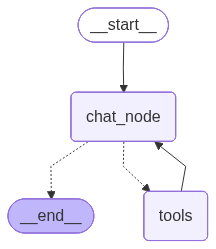

In [103]:
chatbot

In [110]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Give summary of Analyzing Learned Molecular Representations for Property Prediction in 50 word"
                )
            )
        ]
    }
)

C:\Users\viren\AppData\Local\Temp\ipykernel_17812\2923994641.py:13: PydanticDeprecatedSince20: The `schema` method is deprecated; use `model_json_schema` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  "parameters": t.args_schema.schema() if t.args_schema else {"type": "object", "properties": {}}


In [111]:
print(result['messages'][-1].content)

The study evaluates graph‑based neural networks for predicting chemical properties, examining how different learned molecular embeddings capture structural features. By systematically probing representation quality and transferability across tasks, it identifies key architectural choices and representation‑learning strategies that most effectively encode relevant physicochemical information, guiding future model design.


In [112]:
result['messages']

[HumanMessage(content='Give summary of Analyzing Learned Molecular Representations for Property Prediction in 50 word', additional_kwargs={}, response_metadata={}, id='756b4915-a65f-4a4e-bedb-07170b21af25'),
 AIMessage(content='The study evaluates graph‑based neural networks for predicting chemical properties, examining how different learned molecular embeddings capture structural features. By systematically probing representation quality and transferability across tasks, it identifies key architectural choices and representation‑learning strategies that most effectively encode relevant physicochemical information, guiding future model design.', additional_kwargs={}, response_metadata={}, id='b6200e8a-2eb5-49c0-9a58-4034db7ae230', tool_calls=[], invalid_tool_calls=[])]